
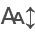

In [15]:
import os, sys
from parser_main_general import analyze_results
from IPython.display import display, Markdown
from itables import init_notebook_mode, options, show
from parser_util import plot_feature_usage_heatmap, combine_winner_matrices
init_notebook_mode(all_interactive=True)
options.pageLength = 50

rules_log = "german_random_forest_rules_59-23_22-08-2025.txt"
entries_log = "german_random_forest_entries_59-23_22-08-2025.txt"
info_log = "german_random_forest_info_59-23_22-08-2025.txt"

# Technical information about experiment (dataset, black-box, explainers parameters)

In [16]:
path="experiments_log/"
file_path = os.path.join(path, info_log)
with open(file_path, "r", encoding="utf-8") as f:
    content = f.read()

print(content)

Reading german_rename_vals.csv from ./data/
Dropped columns:[]

Raw NaN counts per column:
Series([], dtype: int64)
Numeric: ['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age', 'existing_credits', 'num_dependents'] 
 Categorical: ['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker'], Continuous: ['duration', 'credit_amount', 'age']
Num_strat: mean, Cat_strat: most_frequent

Raw NaN counts per column:
Series([], dtype: int64)
Target_map: {'bad': 0, 'good': 1}
Test_size: 0.3, Random_state: 42
SMOTENC used with params: random_state = 42; categorical_features = [0, 2, 3, 5, 6, 8, 9, 11, 13, 14, 16, 18, 19]
Classifier: random_forest Parameters: {'max_depth': 8, 'n_estimators': 50, 'random_state': 42}
models/german_random_forest_08-2025.joblib

WholeData class distribution:
       Count  Percentage
class

# Average metrics of unique non-dominated rules
Non-dominated on (Cov↑, Pre↑) or (Cov_class↑, Pre↑, Len↓), where ↑ indicates a gain and ↓ indicates a loss.

"Unique" means that there are no rules using the same set of attributes but with different values. During filtering, the best rules were chosen based on their distance to the ideal point.

In [17]:
res = analyze_results(
    rules_log=rules_log,
    entries_log=entries_log,
    path=path,
    min_cov=0.01, min_cov_class=0.01, min_pre=0.01,
    random_seed=42,
    use_avg_attr_per_instance = False
)

combined_cat1 = combine_winner_matrices(
    res["winner_matrix_cat1_counts"],
    res["winner_matrix_cat1_ratio"]
)

combined_cat2 = combine_winner_matrices(
    res["winner_matrix_cat2_counts"],
    res["winner_matrix_cat2_ratio"]
)

# --- Classic summaries ---
display(Markdown("### Average Metrics — Non-dominated Unique (Cov↑, Pre↑)"))
show(res["summary_dom1"])

display(Markdown("### Average Metrics —  Non-dominated Unique (Cov_class↑, Pre↑, Len↓)"))
show(res["summary_dom2"])

# --- Pairwise diffs ---
display(Markdown("### Pairwise Average Metrics Diffs — Non-dominated Unique(Cov↑, Pre↑)"))
show(res["diff_dom1"])

display(Markdown("### Pairwise Average Metrics Diffs — Non-dominated Unique(Cov_class↑, Pre↑, Len↓)"))
show(res["diff_dom2"])

### Average Metrics — Non-dominated Unique (Cov↑, Pre↑)

Loading ITables v2.4.4 from the init_notebook_mode cell... (need help?)


### Average Metrics —  Non-dominated Unique (Cov_class↑, Pre↑, Len↓)

Loading ITables v2.4.4 from the init_notebook_mode cell... (need help?)


### Pairwise Average Metrics Diffs — Non-dominated Unique(Cov↑, Pre↑)

Loading ITables v2.4.4 from the init_notebook_mode cell... (need help?)


### Pairwise Average Metrics Diffs — Non-dominated Unique(Cov_class↑, Pre↑, Len↓)

Loading ITables v2.4.4 from the init_notebook_mode cell... (need help?)


# Average metrics for non-dominated ideal rules
Metrics for rules without "unique" filtration as ideal point distance cant be applied for other choice methods.
# --- Rules per step combined ---
display(Markdown("### Average Rules per Step, Cat1 - (Cov↑, Pre↑), Cat2 - (Cov_class↑, Pre↑, Len↓)"))
show(res["rules_per_step_combined"])

# --- Filtered per step combined ---
display(Markdown("### Average Number of Filtered Rules at Each Step, Cat1 - (Cov↑, Pre↑), Cat2 - (Cov_class↑, Pre↑, Len↓)"))
show(res["filtered_per_step_combined"])

# --- Attribute usage ---
display(Markdown("### Average Attribute Usage (Entropy)"))
show(res["attr_usage_avg"])

# --- Jaccard similarity ---
display(Markdown("### Average Jaccard Similarity (Pairs)"))
show(res["jaccard_pairs_avg"])

display(Markdown("### Average Jaccard Similarity (Matrix)"))
show(res["jaccard_matrix_avg"])

display(Markdown("### Attribute Usage — Non-Filtered (Avg per Instance)"))
plot_feature_usage_heatmap(
    res["attr_usage_original_tbl"], "Feature", "Explainer", "Count", all_features=res["attribute_universe"], vmax = 5*100, title = "German_RF_Attribute_Usage_Non_Filtered", save =True
)
# Cat1 Unique
display(Markdown("### Attribute Usage — Non-dominated Unique (Cov↑, Pre↑) (Avg per Instance)"))
plot_feature_usage_heatmap(
    res["attr_usage_cat1_tbl"], "Feature", "Explainer", "Count", all_features=res["attribute_universe"], vmax = 5*100, title = "German_RF_Attribute_Usage_Non_dominated_Unique(Cov,Pre)", save =True
)
# Cat2 Unique
display(Markdown("### Attribute Usage — Non-dominated Unique (Cov_class↑, Pre↑, Len↓) (Avg per Instance)"))
plot_feature_usage_heatmap(
    res["attr_usage_cat2_tbl"], "Feature", "Explainer", "Count", all_features=res["attribute_universe"], vmax = 5*100, title = "German_RF_Attribute_Usage_Non_dominated_Unique(Cov_class,Pre,Len)", save =True
)
Ideal means rules with best measures (e.g. (Cov,Pre)) chosen for each instance among generated and filtered explanations (and then averaged)

In [18]:
# --- Averaged metrics per explainer for each selection method ---
for m, df in res["choice_tables_cat1"].items():
    display(Markdown(f"### Average Metrics Non-dominated (Cov↑, Pre↑), ideal rules — {m} choice method"))
    show(df)

for m, df in res["choice_tables_cat2"].items():
    display(Markdown(f"### Average Metrics Non-dominated (Cov_class↑, Pre↑, Len↓), ideal rules — {m} choice method"))
    show(df)

# --- Winner matrices ---
display(Markdown("### Winner Matrix — Non-dominated (Cov↑, Pre↑)"))
show(combined_cat1)

display(Markdown("### Winner Matrix — Non-dominated (Cov_class↑, Pre↑, Len↓)"))
show(combined_cat2)

### Average Metrics Non-dominated (Cov↑, Pre↑), ideal rules — distance choice method

Loading ITables v2.4.4 from the init_notebook_mode cell... (need help?)


### Average Metrics Non-dominated (Cov↑, Pre↑), ideal rules — random choice method

Loading ITables v2.4.4 from the init_notebook_mode cell... (need help?)


### Average Metrics Non-dominated (Cov↑, Pre↑), ideal rules — sum choice method

Loading ITables v2.4.4 from the init_notebook_mode cell... (need help?)


### Average Metrics Non-dominated (Cov↑, Pre↑), ideal rules — product choice method

Loading ITables v2.4.4 from the init_notebook_mode cell... (need help?)


### Average Metrics Non-dominated (Cov_class↑, Pre↑, Len↓), ideal rules — distance choice method

Loading ITables v2.4.4 from the init_notebook_mode cell... (need help?)


### Average Metrics Non-dominated (Cov_class↑, Pre↑, Len↓), ideal rules — random choice method

Loading ITables v2.4.4 from the init_notebook_mode cell... (need help?)


### Average Metrics Non-dominated (Cov_class↑, Pre↑, Len↓), ideal rules — sum choice method

Loading ITables v2.4.4 from the init_notebook_mode cell... (need help?)


### Average Metrics Non-dominated (Cov_class↑, Pre↑, Len↓), ideal rules — product choice method

Loading ITables v2.4.4 from the init_notebook_mode cell... (need help?)


### Winner Matrix — Non-dominated (Cov↑, Pre↑)

Loading ITables v2.4.4 from the init_notebook_mode cell... (need help?)


### Winner Matrix — Non-dominated (Cov_class↑, Pre↑, Len↓)

Loading ITables v2.4.4 from the init_notebook_mode cell... (need help?)


# Number of rules per step

In [19]:
# --- Rules per step combined ---
display(Markdown("### Average Rules per Step, Cat1 - (Cov↑, Pre↑), Cat2 - (Cov_class↑, Pre↑, Len↓)"))
show(res["rules_per_step_combined"])

# --- Filtered per step combined ---
display(Markdown("### Average Number of Filtered Rules at Each Step, Cat1 - (Cov↑, Pre↑), Cat2 - (Cov_class↑, Pre↑, Len↓)"))
show(res["filtered_per_step_combined"])

### Average Rules per Step, Cat1 - (Cov↑, Pre↑), Cat2 - (Cov_class↑, Pre↑, Len↓)

Loading ITables v2.4.4 from the init_notebook_mode cell... (need help?)


### Average Number of Filtered Rules at Each Step, Cat1 - (Cov↑, Pre↑), Cat2 - (Cov_class↑, Pre↑, Len↓)

Loading ITables v2.4.4 from the init_notebook_mode cell... (need help?)


# Average metrics of explanation similarity

- **Entropy** shows the average proportion of attributes used in explanations generated for a single instance.  
- **Jaccard** shows how similar (in terms of used attributes) the explanations for a single instance were, on average.

In [20]:
# --- Attribute usage ---
display(Markdown("### Average Attribute Usage (Entropy)"))
show(res["attr_usage_avg"])

# --- Jaccard similarity ---
display(Markdown("### Average Jaccard Similarity (Pairs)"))
show(res["jaccard_pairs_avg"])

display(Markdown("### Average Jaccard Similarity (Matrix)"))
show(res["jaccard_matrix_avg"])

### Average Attribute Usage (Entropy)

Loading ITables v2.4.4 from the init_notebook_mode cell... (need help?)


### Average Jaccard Similarity (Pairs)

Loading ITables v2.4.4 from the init_notebook_mode cell... (need help?)


### Average Jaccard Similarity (Matrix)

Loading ITables v2.4.4 from the init_notebook_mode cell... (need help?)


# Attribute usage in all generated rules 

### Attribute Usage — Raw rules

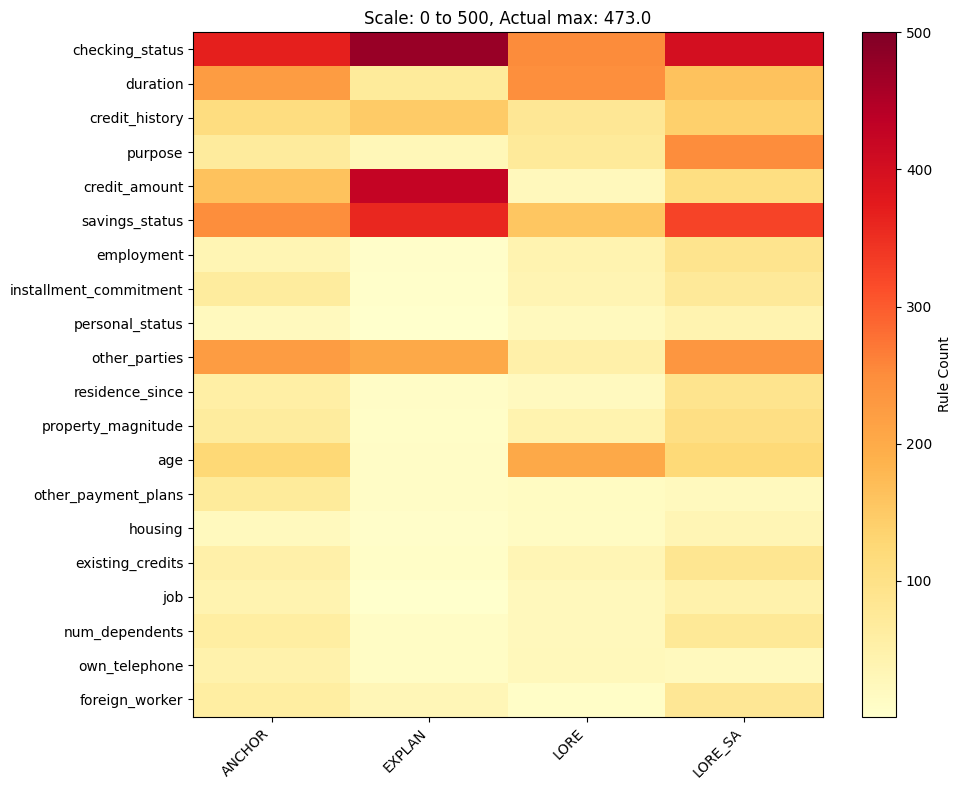

### Attribute Usage — Non-dominated Unique (Cov↑, Pre↑)

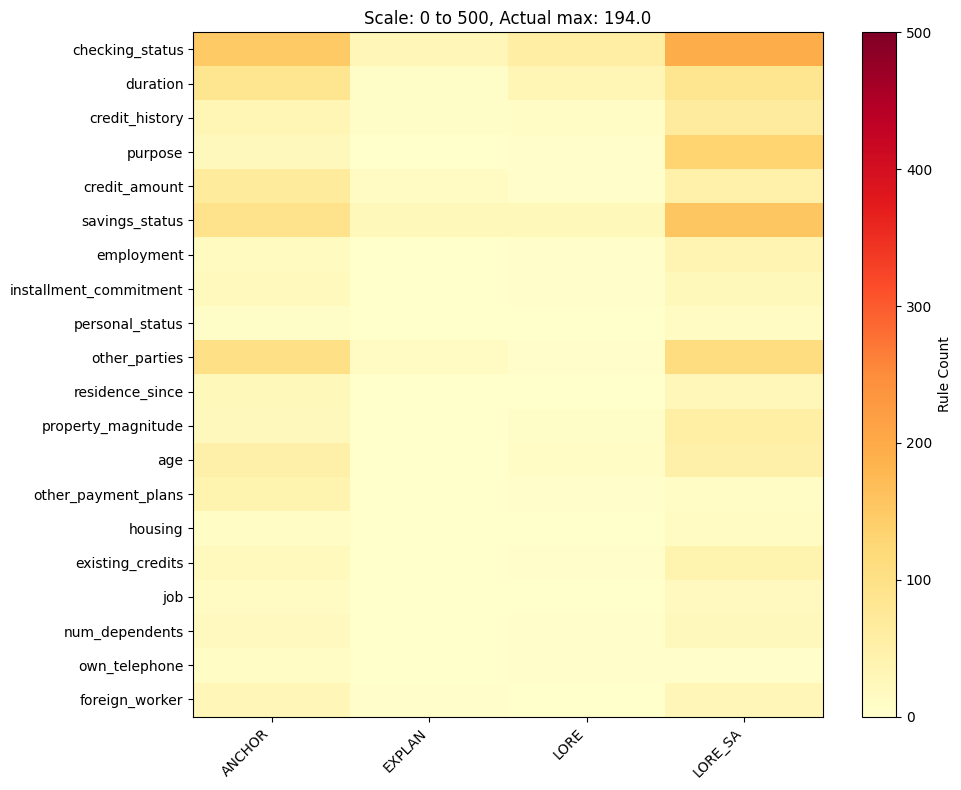

### Attribute Usage — Non-dominated Unique (Cov_class↑, Pre↑, Len↓)

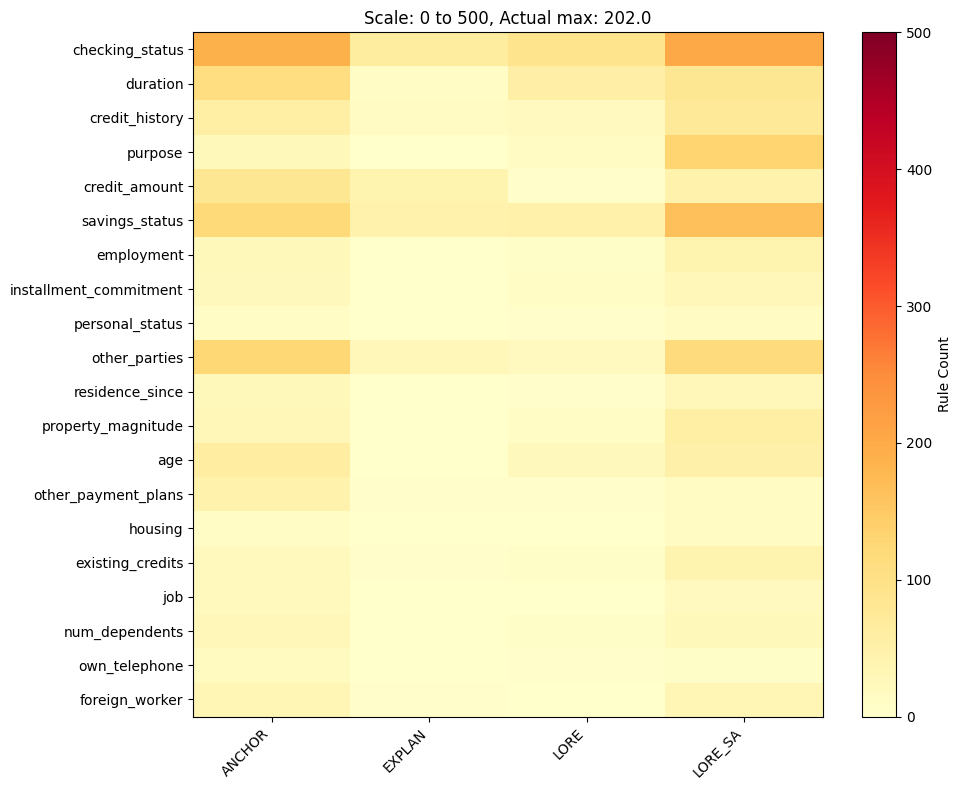

In [21]:
display(Markdown("### Attribute Usage — Raw rules"))
plot_feature_usage_heatmap(
    res["attr_usage_original_tbl"], "Feature", "Explainer", "Count", all_features=res["attribute_universe"], vmax = 5*100, title = "German_RF_Attribute_Usage_Non_Filtered", save =False
)
# Cat1 Unique
display(Markdown("### Attribute Usage — Non-dominated Unique (Cov↑, Pre↑)"))
plot_feature_usage_heatmap(
    res["attr_usage_cat1_tbl"], "Feature", "Explainer", "Count", all_features=res["attribute_universe"], vmax = 5*100, title = "German_RF_Attribute_Usage_Non_dominated_Unique(Cov,Pre)", save =False
)
# Cat2 Unique
display(Markdown("### Attribute Usage — Non-dominated Unique (Cov_class↑, Pre↑, Len↓)"))
plot_feature_usage_heatmap(
    res["attr_usage_cat2_tbl"], "Feature", "Explainer", "Count", all_features=res["attribute_universe"], vmax = 5*100, title = "German_RF_Attribute_Usage_Non_dominated_Unique(Cov_class,Pre,Len)", save =False
)